Test for the best lambda parameter

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from nd_phase_unwrap import io
import os 
import numpy as np

data_path = REPO_ROOT / 'test_data'
in_path = data_path / '3+1D_phantom'
out_path_mask = data_path / '4DphantomLambda'

truth = io.load_numpy_data(in_path/"0wraps.npy")
mask = np.abs(truth) != 0



## Voxels different from ground truth vs. neighbourhood weight (lambda)

For each wrap count (1, 3, 5) and each `neighbourhood_weight` (lambda) tested by `demo/lambdaTest.py`, compare the unwrapped result against the true continuous phase.

The true continuous phase for a `{n}wraps` file is `factor * angle(0wraps.npy)` with `factor = 1 + 2*n`, since `0wraps.npy` holds the already-unwrapped base phase and each wrap file is that phase multiplied by its wrap factor before being (re)wrapped to `(-pi, pi]`.

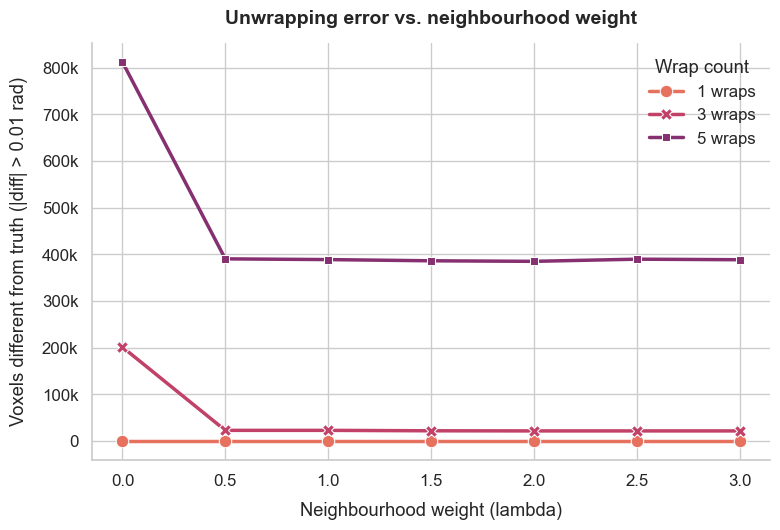

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

lambda_path = data_path / '4DphantomLambda'
wraps_list = [1, 3, 5]
lambdas = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
tol = 1e-2  # rad; float32 round-trip noise is ~1e-6, true errors are multiples of 2*pi

truth_phase = np.angle(truth)  # 0wraps.npy is already the true continuous (unwrapped) phase
mask = np.abs(truth) != 0

records = []
for num_wraps in wraps_list:
    factor = 1 + 2 * num_wraps
    target = factor * truth_phase
    for lbda in lambdas:
        lbda_str = str(lbda).replace('.', '_')
        arr = io.load_numpy_data(lambda_path / f'{num_wraps}wraps_{lbda_str}_unwrapped.npy')
        diff = arr - target
        n_diff = int(np.sum(np.abs(diff[mask]) > tol))
        records.append({'Wrap count': f'{num_wraps} wraps', 'lambda': lbda, 'voxels_diff': n_diff})

df = pd.DataFrame.from_records(records)

sns.set_theme(context='notebook', style='whitegrid', font_scale=1.1)
palette = sns.color_palette('flare', n_colors=len(wraps_list))

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.lineplot(
    data=df, x='lambda', y='voxels_diff', hue='Wrap count', style='Wrap count',
    palette=palette, markers=True, dashes=False, markersize=9, linewidth=2.5, ax=ax,
)

ax.set_xlabel('Neighbourhood weight (lambda)', labelpad=10)
ax.set_ylabel(f'Voxels different from truth (|diff| > {tol} rad)', labelpad=10)
ax.set_title('Unwrapping error vs. neighbourhood weight', fontsize=14, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k' if v else '0'))
sns.despine(ax=ax)
ax.legend(title='Wrap count', frameon=False, loc='upper right')
fig.tight_layout()
plt.show()